# Country-Level Value for Living Analysis

**Research question:** Are 'good value' countries clustered in particular world regions, and what are the indicators of such countries?

**Hypothesis:** High-value countries will cluster in Eastern Europe and Southeast/South Asia - middle-income regions where quality infrastructure is available but costs remain low. Traditional top-ranked countries (Switzerland, Australia, Denmark) will score poorly on value because their high quality comes at an even higher price. The strongest predictor of value will be cost of living, not quality score: most countries achieve similar quality levels, but cost separates the sweet spots from the expensive ones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import warnings
warnings.simplefilter('ignore')

YEAR = 2025

REGION_COLORS = {
    'Eastern Europe':    '#3B82F6',
    'Western Europe':    '#6366F1',
    'North America':     '#F59E0B',
    'Latin America':     '#10B981',
    'East Asia':         '#EF4444',
    'Southeast Asia':    '#EC4899',
    'South Asia':        '#8B5CF6',
    'MENA':              '#F97316',
    'Sub-Saharan Africa':'#6B7280',
    'Oceania':           '#14B8A6',
    'Other':             '#94A3B8',
}

REGION_MAP = {
    'Romania':'Eastern Europe','Bulgaria':'Eastern Europe','Hungary':'Eastern Europe',
    'Czech Republic':'Eastern Europe','Poland':'Eastern Europe','Serbia':'Eastern Europe',
    'Croatia':'Eastern Europe','Slovakia':'Eastern Europe','Slovenia':'Eastern Europe',
    'Ukraine':'Eastern Europe','Belarus':'Eastern Europe','Russia':'Eastern Europe',
    'Bosnia And Herzegovina':'Eastern Europe','North Macedonia':'Eastern Europe',
    'Albania':'Eastern Europe','Moldova':'Eastern Europe','Estonia':'Eastern Europe',
    'Latvia':'Eastern Europe','Lithuania':'Eastern Europe','Montenegro':'Eastern Europe',
    'Georgia':'Eastern Europe','Armenia':'Eastern Europe','Azerbaijan':'Eastern Europe',
    'Kazakhstan':'Eastern Europe','Kosovo (Disputed Territory)':'Eastern Europe',
    'Germany':'Western Europe','France':'Western Europe','Spain':'Western Europe',
    'Italy':'Western Europe','Portugal':'Western Europe','Netherlands':'Western Europe',
    'Belgium':'Western Europe','Switzerland':'Western Europe','Austria':'Western Europe',
    'Sweden':'Western Europe','Norway':'Western Europe','Denmark':'Western Europe',
    'Finland':'Western Europe','Ireland':'Western Europe','Luxembourg':'Western Europe',
    'Greece':'Western Europe','Cyprus':'Western Europe','Malta':'Western Europe',
    'Iceland':'Western Europe','United Kingdom':'Western Europe',
    'United States':'North America','Canada':'North America','Mexico':'North America',
    'Puerto Rico':'North America',
    'Brazil':'Latin America','Argentina':'Latin America','Colombia':'Latin America',
    'Chile':'Latin America','Peru':'Latin America','Ecuador':'Latin America',
    'Bolivia':'Latin America','Uruguay':'Latin America','Paraguay':'Latin America',
    'Costa Rica':'Latin America','Guatemala':'Latin America',
    'Dominican Republic':'Latin America','Venezuela':'Latin America',
    'Jamaica':'Latin America','Trinidad And Tobago':'Latin America','Panama':'Latin America',
    'China':'East Asia','Japan':'East Asia','South Korea':'East Asia',
    'Taiwan':'East Asia','Hong Kong (China)':'East Asia',
    'Thailand':'Southeast Asia','Vietnam':'Southeast Asia','Indonesia':'Southeast Asia',
    'Malaysia':'Southeast Asia','Philippines':'Southeast Asia','Singapore':'Southeast Asia',
    'Cambodia':'Southeast Asia',
    'India':'South Asia','Pakistan':'South Asia','Bangladesh':'South Asia',
    'Nepal':'South Asia','Sri Lanka':'South Asia',
    'Israel':'MENA','Turkey':'MENA','Iran':'MENA','Iraq':'MENA',
    'Jordan':'MENA','Lebanon':'MENA','Saudi Arabia':'MENA',
    'United Arab Emirates':'MENA','Qatar':'MENA','Kuwait':'MENA',
    'Bahrain':'MENA','Oman':'MENA','Morocco':'MENA','Egypt':'MENA',
    'Algeria':'MENA','Tunisia':'MENA','Libya':'MENA',
    'South Africa':'Sub-Saharan Africa','Nigeria':'Sub-Saharan Africa',
    'Kenya':'Sub-Saharan Africa','Ghana':'Sub-Saharan Africa',
    'Tanzania':'Sub-Saharan Africa','Uganda':'Sub-Saharan Africa',
    'Zimbabwe':'Sub-Saharan Africa','Cameroon':'Sub-Saharan Africa',
    'Australia':'Oceania','New Zealand':'Oceania',
}

# Mapping from Numbeo country names to World Bank country names
WB_NAME_MAP = {
    'Bosnia And Herzegovina': 'Bosnia and Herzegovina',
    'Czech Republic':         'Czechia',
    'Egypt':                  'Egypt, Arab Rep.',
    'Hong Kong (China)':      'Hong Kong SAR, China',
    'Iran':                   'Iran, Islamic Rep.',
    'Puerto Rico':            'Puerto Rico (US)',
    'Russia':                 'Russian Federation',
    'Slovakia':               'Slovak Republic',
    'South Korea':            'Korea, Rep.',
    'Turkey':                 'Turkiye',
    'Vietnam':                'Viet Nam',
}

In [2]:
def load_country_sheet(filepath, year):
    return pd.read_excel(filepath, sheet_name=str(year))

cost      = load_country_sheet('../data/raw/numbeo_cost_of_living_country.xlsx', YEAR)
safety    = load_country_sheet('../data/raw/numbeo_crime_country.xlsx',           YEAR)
health    = load_country_sheet('../data/raw/numbeo_health_care_country.xlsx',     YEAR)
pollution = load_country_sheet('../data/raw/numbeo_pollution_country.xlsx',       YEAR)
traffic   = load_country_sheet('../data/raw/number_traffic_country.xlsx',         YEAR)

# Global traffic bounds across all years (same normalization approach as city-level)
_traffic_all = pd.concat([
    pd.read_excel('../data/raw/number_traffic_country.xlsx', sheet_name=s)
    for s in pd.ExcelFile('../data/raw/number_traffic_country.xlsx').sheet_names
    if s.strip().isdigit()
])
TRAFFIC_GLOBAL_MIN = _traffic_all['Traffic Index'].min()
TRAFFIC_GLOBAL_MAX = _traffic_all['Traffic Index'].max()
print(f'Country Traffic Index global range: {TRAFFIC_GLOBAL_MIN:.1f} – {TRAFFIC_GLOBAL_MAX:.1f}')

df = (
    cost[['Country', 'Cost of Living Index', 'Local Purchasing Power Index']]
    .merge(safety[['Country', 'Safety Index']],       on='Country')
    .merge(health[['Country', 'Health Care Index']],  on='Country')
    .merge(pollution[['Country', 'Pollution Index']], on='Country')
    .merge(traffic[['Country', 'Traffic Index']],     on='Country')
)

df['region']        = df['Country'].map(REGION_MAP).fillna('Other')
df['pollution_inv'] = 100 - df['Pollution Index']
df['traffic_score'] = (
    100 * (1 - (df['Traffic Index'] - TRAFFIC_GLOBAL_MIN)
               / (TRAFFIC_GLOBAL_MAX - TRAFFIC_GLOBAL_MIN))
)
df['quality_score'] = df[['Safety Index', 'Health Care Index',
                           'pollution_inv', 'traffic_score']].mean(axis=1)
df['value_index']   = (df['quality_score'] / df['Cost of Living Index']).round(3)
df['affordability'] = (df['Local Purchasing Power Index'] / df['Cost of Living Index']).round(3)
df['size_bubble']   = df['value_index'].clip(lower=0)

# Join World Bank GDP and income group
wb = pd.read_csv('../data/clean/world_bank_latest.csv')
df['wb_name'] = df['Country'].replace(WB_NAME_MAP)
df = df.merge(
    wb[['country', 'gdp_per_capita_ppp', 'income_group']].rename(columns={'country': 'wb_name'}),
    on='wb_name', how='left'
)

print(f'Countries with all sub-indices in {YEAR}: {len(df)}')
print(f'Countries with World Bank GDP data:   {df["gdp_per_capita_ppp"].notna().sum()}')
print()
print(df[['Country', 'quality_score', 'Cost of Living Index', 'value_index']]
      .sort_values('value_index', ascending=False).head(10).to_string(index=False))

Country Traffic Index global range: 69.4 – 334.9
Countries with all sub-indices in 2025: 89
Countries with World Bank GDP data:   86

   Country  quality_score  Cost of Living Index  value_index
  Pakistan      51.836770                  17.8        2.912
     India      49.344303                  19.5        2.530
    Russia      56.128908                  22.3        2.517
   Belarus      59.438701                  25.0        2.378
   Ukraine      54.609605                  24.6        2.220
   Tunisia      54.633710                  25.5        2.142
   Vietnam      55.308522                  26.6        2.079
     Egypt      39.325000                  19.0        2.070
Kazakhstan      54.407392                  26.6        2.045
 Indonesia      50.237241                  24.6        2.042


## Index Construction

**Composite quality score** = arithmetic mean of four dimensions:
- Safety Index (Numbeo)
- Health Care Index (Numbeo)
- 100 − Pollution Index (inverted)
- Traffic score - normalised to 0–100 using global min/max across all years (the Numbeo Traffic Index is not bounded at 100; raw values range from ~70 to ~335, so `100 − Traffic Index` would produce negative numbers for most countries)

**Value index** = composite quality score ÷ Cost of Living Index

**Key methodological note:** The country-level Cost of Living Index is not anchored to New York City = 100. The United States as a whole country appears at approximately 65–75, reflecting that NYC is one expensive city within a much larger, cheaper country. This means raw index values can be compared across years - a country rising from 30 to 45 reflects a genuine increase in relative costs, not a re-anchoring artefact. This is a meaningful advantage over the city-level data for time-series analysis.

We deliberately do **not** use Numbeo's own composite Quality of Life Index, which already incorporates cost of living and defeats the purpose of this analysis.

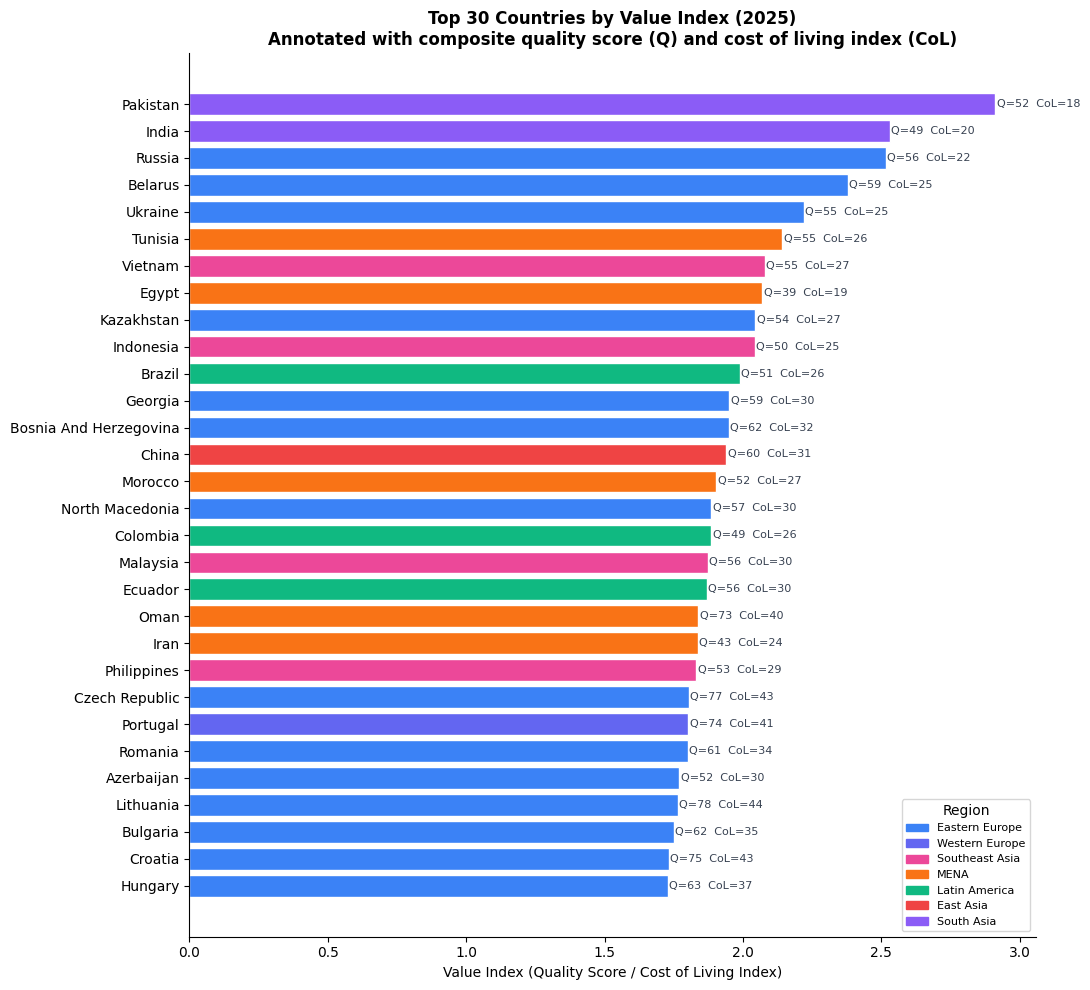

In [3]:
top30 = df.nlargest(30, 'value_index').sort_values('value_index')
colors = [REGION_COLORS.get(r, REGION_COLORS['Other']) for r in top30['region']]

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(top30['Country'], top30['value_index'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, top30.iterrows()):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"Q={row['quality_score']:.0f}  CoL={row['Cost of Living Index']:.0f}",
            va='center', fontsize=8, color='#374151')

ax.set_title(
    f'Top 30 Countries by Value Index ({YEAR})\n'
    'Annotated with composite quality score (Q) and cost of living index (CoL)',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Value Index (Quality Score / Cost of Living Index)')
ax.spines[['top', 'right']].set_visible(False)

seen = {}
for _, row in top30.iterrows():
    r = row['region']
    if r not in seen:
        seen[r] = REGION_COLORS.get(r, REGION_COLORS['Other'])
patches = [plt.Rectangle((0,0),1,1, color=c, label=r) for r, c in seen.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8, title='Region')
plt.tight_layout()
plt.show()

---
## Section 2: The Value Quadrant

Every country plotted by cost (x-axis) and quality (y-axis). Dividing lines sit at the median cost and median quality across all 89 countries:

- **Top-left (Sweet Spots):** High quality, low cost
- **Top-right (Prestigious):** High quality, high cost - traditional liveability top countries
- **Bottom-left (Budget):** Low quality, low cost
- **Bottom-right (Traps):** Low quality, high cost

Bubble size reflects the value index.

In [4]:
med_cost    = df['Cost of Living Index'].median()
med_quality = df['quality_score'].median()

top15_set = set(df.nlargest(15, 'value_index')['Country'])
flagship  = {'Switzerland', 'Denmark', 'Australia', 'Norway', 'Iceland', 'Japan'}

def label_country(row):
    if row['Country'] in top15_set: return row['Country']
    if row['Country'] in flagship:  return row['Country'] + ' *'
    return ''

df['label'] = df.apply(label_country, axis=1)

fig = px.scatter(
    df,
    x='Cost of Living Index',
    y='quality_score',
    size='size_bubble',
    color='region',
    hover_name='Country',
    text='label',
    color_discrete_map=REGION_COLORS,
    hover_data={
        'value_index':          ':.3f',
        'quality_score':        ':.1f',
        'Cost of Living Index': ':.1f',
        'size_bubble':          False,
        'region':               False,
    },
    title=f'Quality vs Cost of Living - Country Value Quadrant ({YEAR})\n'
          '(* = traditional top-ranked countries  |  bubble size = value index)',
    labels={
        'Cost of Living Index': 'Cost of Living Index',
        'quality_score':        'Composite Quality Score (0–100)',
        'region':               'Region',
    },
    size_max=22,
)

fig.add_vline(x=med_cost,    line_dash='dot', line_color='grey',
              annotation_text='Median cost',    annotation_position='top right')
fig.add_hline(y=med_quality, line_dash='dot', line_color='grey',
              annotation_text='Median quality', annotation_position='right')

fig.update_traces(textposition='top center', textfont=dict(size=9))
fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(font=dict(size=9)),
    annotations=fig.layout.annotations + (
        dict(x=med_cost*0.45,  y=med_quality*1.12, text='Sweet Spots',
             showarrow=False, font=dict(size=11, color='#10B981')),
        dict(x=med_cost*1.55,  y=med_quality*1.12, text='Prestigious',
             showarrow=False, font=dict(size=11, color='#6366F1')),
        dict(x=med_cost*0.45,  y=med_quality*0.55, text='Budget',
             showarrow=False, font=dict(size=11, color='#94A3B8')),
        dict(x=med_cost*1.55,  y=med_quality*0.55, text='Traps',
             showarrow=False, font=dict(size=11, color='#EF4444')),
    )
)
fig.show()

---
## Section 3: Regional Clustering

The core question is whether good-value countries form geographic clusters. Two charts examine this:

1. **Box plots** - distribution of value index within each region. A region with a tight, high distribution has consistently good value; a wide spread means mixed results within the region.

2. **Quality vs cost decomposition** - for each region, what is the average quality score and average cost of living? This separates two paths to high value: (a) genuinely better quality, or (b) simply cheaper costs.

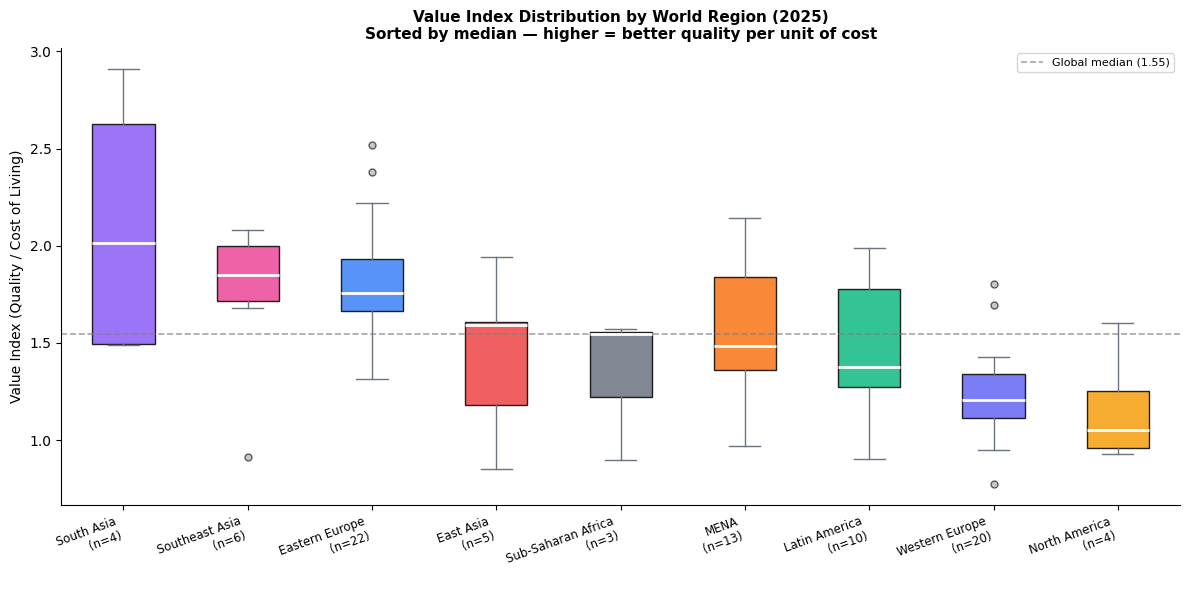


Median value index by region:
  South Asia          : median=2.012  n=4  top country=Pakistan
  Southeast Asia      : median=1.852  n=6  top country=Vietnam
  Eastern Europe      : median=1.757  n=22  top country=Russia
  East Asia           : median=1.593  n=5  top country=China
  Sub-Saharan Africa  : median=1.546  n=3  top country=South Africa
  MENA                : median=1.485  n=13  top country=Tunisia
  Latin America       : median=1.376  n=10  top country=Brazil
  Western Europe      : median=1.206  n=20  top country=Portugal
  North America       : median=1.051  n=4  top country=Mexico


In [5]:
# Sort regions by median value index
region_medians = df.groupby('region')['value_index'].median().sort_values(ascending=False)
region_order   = region_medians.index.tolist()

# Only include regions with at least 3 countries
region_counts = df['region'].value_counts()
region_order  = [r for r in region_order if region_counts.get(r, 0) >= 3]

fig, ax = plt.subplots(figsize=(12, 6))

data_by_region = [df[df['region'] == r]['value_index'].dropna().values
                  for r in region_order]
bp = ax.boxplot(data_by_region, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, region in zip(bp['boxes'], region_order):
    patch.set_facecolor(REGION_COLORS.get(region, REGION_COLORS['Other']))
    patch.set_alpha(0.85)

for whisker, cap in zip(bp['whiskers'], bp['caps']):
    whisker.set_color('#6B7280')
    cap.set_color('#6B7280')

for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='#9CA3AF', markersize=5, alpha=0.6)

ax.set_xticks(range(1, len(region_order)+1))
ax.set_xticklabels(
    [f'{r}\n(n={region_counts[r]})' for r in region_order],
    fontsize=8.5, rotation=20, ha='right')
ax.set_ylabel('Value Index (Quality / Cost of Living)')
ax.set_title(
    f'Value Index Distribution by World Region ({YEAR})\n'
    'Sorted by median - higher = better quality per unit of cost',
    fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(df['value_index'].median(), color='grey', linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'Global median ({df["value_index"].median():.2f})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('\nMedian value index by region:')
for r in region_order:
    subset = df[df['region'] == r]
    print(f'  {r:20s}: median={subset["value_index"].median():.3f}'
          f'  n={len(subset)}'
          f'  top country={subset.nlargest(1,"value_index")["Country"].values[0]}')

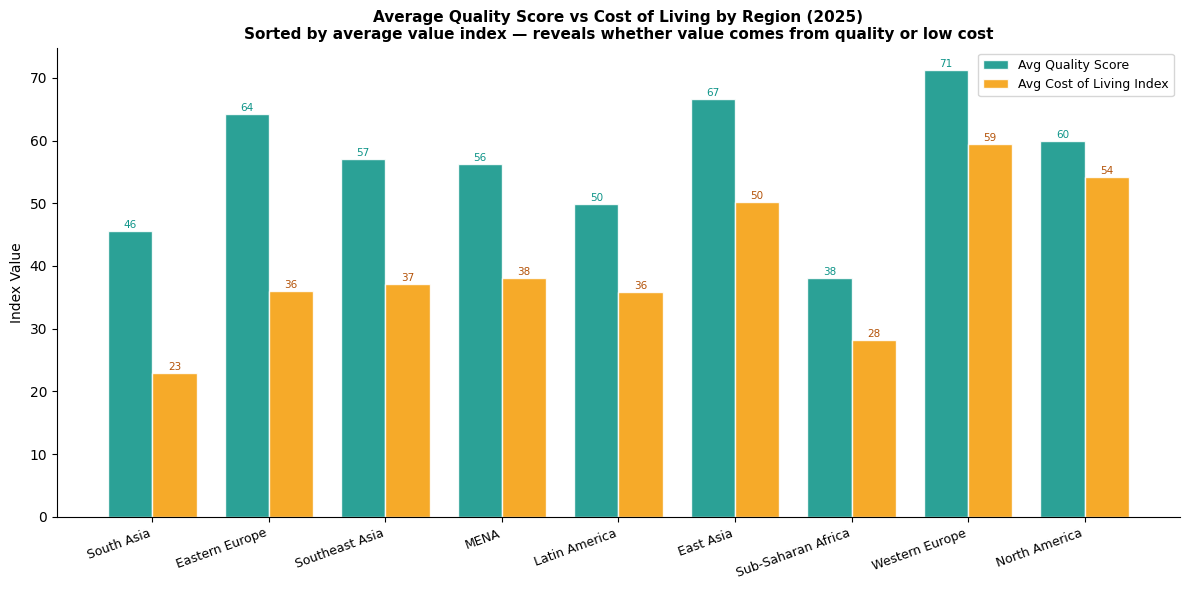


Region summary (sorted by avg value index):
            region  avg_quality  avg_cost  avg_value  n
        South Asia    45.585358 22.925000   2.106000  4
    Eastern Europe    64.197378 35.977273   1.826864 22
    Southeast Asia    57.088944 37.083333   1.735833  6
              MENA    56.246197 38.069231   1.573462 13
     Latin America    49.937439 35.800000   1.454800 10
         East Asia    66.653983 50.160000   1.435400  5
Sub-Saharan Africa    38.113167 28.200000   1.337333  3
    Western Europe    71.230372 59.410000   1.236000 20
     North America    59.851919 54.200000   1.159250  4


In [6]:
# For each region, compute average quality score and average cost of living
# Sort by average value index so the best-value regions appear first
region_summary = (
    df[df['region'].isin(region_order)]
    .groupby('region')
    .agg(
        avg_quality=('quality_score',        'mean'),
        avg_cost=   ('Cost of Living Index',  'mean'),
        avg_value=  ('value_index',           'mean'),
        n=          ('Country',               'count'),
    )
    .sort_values('avg_value', ascending=False)
    .reset_index()
)

x = np.arange(len(region_summary))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars_q = ax.bar(x - width/2, region_summary['avg_quality'], width,
                label='Avg Quality Score', color='#0D9488', alpha=0.88, edgecolor='white')
bars_c = ax.bar(x + width/2, region_summary['avg_cost'],    width,
                label='Avg Cost of Living Index', color='#F59E0B', alpha=0.88, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(region_summary['region'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Index Value')
ax.set_title(
    f'Average Quality Score vs Cost of Living by Region ({YEAR})\n'
    'Sorted by average value index - reveals whether value comes from quality or low cost',
    fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

for bar in bars_q:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', fontsize=7.5, color='#0D9488')
for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', fontsize=7.5, color='#B45309')

plt.tight_layout()
plt.show()

print('\nRegion summary (sorted by avg value index):')
print(region_summary[['region','avg_quality','avg_cost','avg_value','n']].to_string(index=False))

---
## Section 4: What Drives Top Countries?

Are top-value countries strong across all quality dimensions, or are their scores built on one standout factor? The heatmap shows each quality dimension for the top 25 value countries, with rows sorted by value index. Green = high score, red = low score on that dimension.

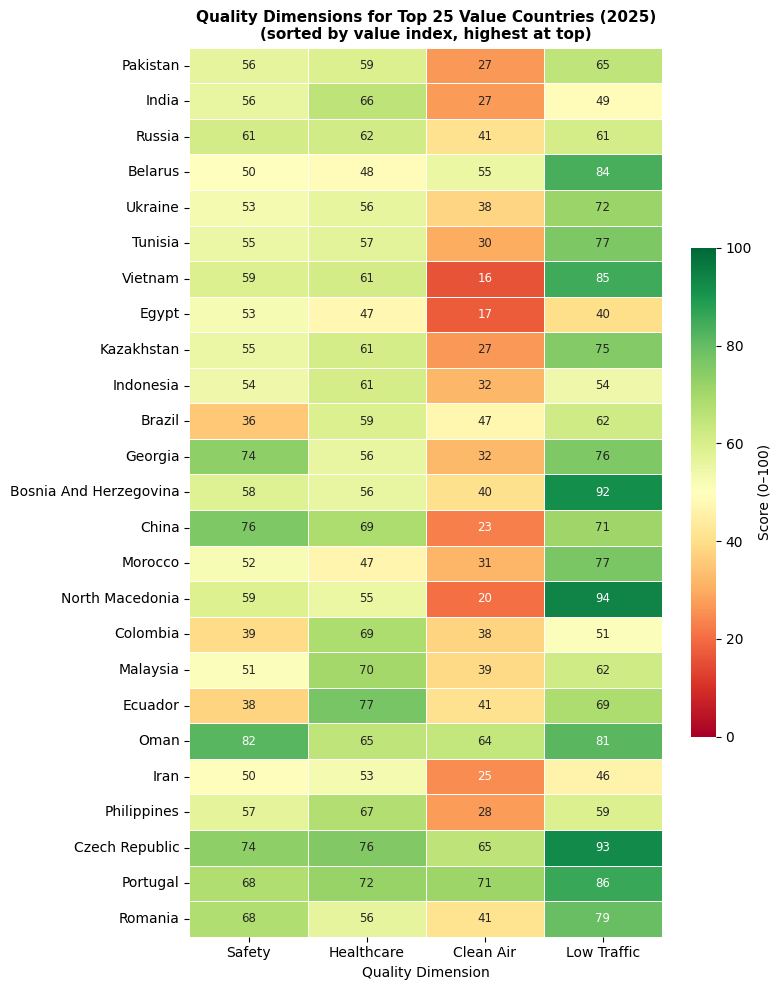


Dimension averages - top 25 vs all countries:
  Safety         : top-25 avg=57.3  all avg=59.3  diff=-2.1
  Healthcare     : top-25 avg=61.0  all avg=64.7  diff=-3.7
  Clean Air      : top-25 avg=36.6  all avg=47.1  diff=-10.5
  Low Traffic    : top-25 avg=70.4  all avg=72.1  diff=-1.8


In [7]:
top25_hm = df.nlargest(25, 'value_index').sort_values('value_index', ascending=False)

dim_labels = {
    'Safety Index':     'Safety',
    'Health Care Index':'Healthcare',
    'pollution_inv':    'Clean Air',
    'traffic_score':    'Low Traffic',
}
hm_data       = top25_hm[list(dim_labels)].rename(columns=dim_labels)
hm_data.index = top25_hm['Country'].values

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    hm_data, ax=ax,
    cmap='RdYlGn', vmin=0, vmax=100,
    annot=True, fmt='.0f', annot_kws={'size': 8.5},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Score (0–100)', 'shrink': 0.55}
)
ax.set_title(
    f'Quality Dimensions for Top 25 Value Countries ({YEAR})\n'
    '(sorted by value index, highest at top)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Quality Dimension')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nDimension averages - top 25 vs all countries:')
for dim, lbl in dim_labels.items():
    t = top25_hm[dim].mean()
    a = df[dim].mean()
    print(f'  {lbl:15s}: top-25 avg={t:.1f}  all avg={a:.1f}  diff={t-a:+.1f}')

---
## Section 5: Economic Indicators - What Predicts Value?

Two analyses using World Bank data test whether value is an economic phenomenon:

1. **GDP per capita vs value index** - does income level predict how much quality you get per dollar? We expect a negative relationship: richer countries cost more relative to the quality they offer, because high wages raise prices faster than they raise quality perception scores.

2. **Income group comparison** - World Bank groups countries into four income tiers. Upper-middle income countries are predicted to dominate the top-value tier: they are wealthy enough to maintain public services but not so expensive that costs outrun quality.

3. **Dimension correlations** - which of the four quality sub-indices most strongly predicts membership in the top-value quartile? This identifies which dimensions differentiate sweet-spot countries from the rest.

In [8]:
df_wb = df[df['gdp_per_capita_ppp'].notna()].copy()
df_wb['log_gdp'] = np.log10(df_wb['gdp_per_capita_ppp'])

corr = df_wb[['log_gdp','value_index']].corr().iloc[0,1]

fig = px.scatter(
    df_wb,
    x='gdp_per_capita_ppp',
    y='value_index',
    color='region',
    hover_name='Country',
    color_discrete_map=REGION_COLORS,
    log_x=True,
    trendline='ols',
    hover_data={
        'value_index':         ':.3f',
        'gdp_per_capita_ppp':  ':,.0f',
        'region':              False,
    },
    title=f'GDP per Capita (PPP) vs Value Index ({YEAR})  |  r = {corr:.2f}\n'
          'Countries with high GDP tend to be expensive relative to their quality',
    labels={
        'gdp_per_capita_ppp': 'GDP per Capita, PPP (log scale, USD)',
        'value_index':        'Value Index',
        'region':             'Region',
    },
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                  legend=dict(font=dict(size=9)))
fig.show()

print(f'Pearson r (log GDP vs value index): {corr:.3f}')
print(f'Countries included: {len(df_wb)}')

Pearson r (log GDP vs value index): -0.560
Countries included: 86


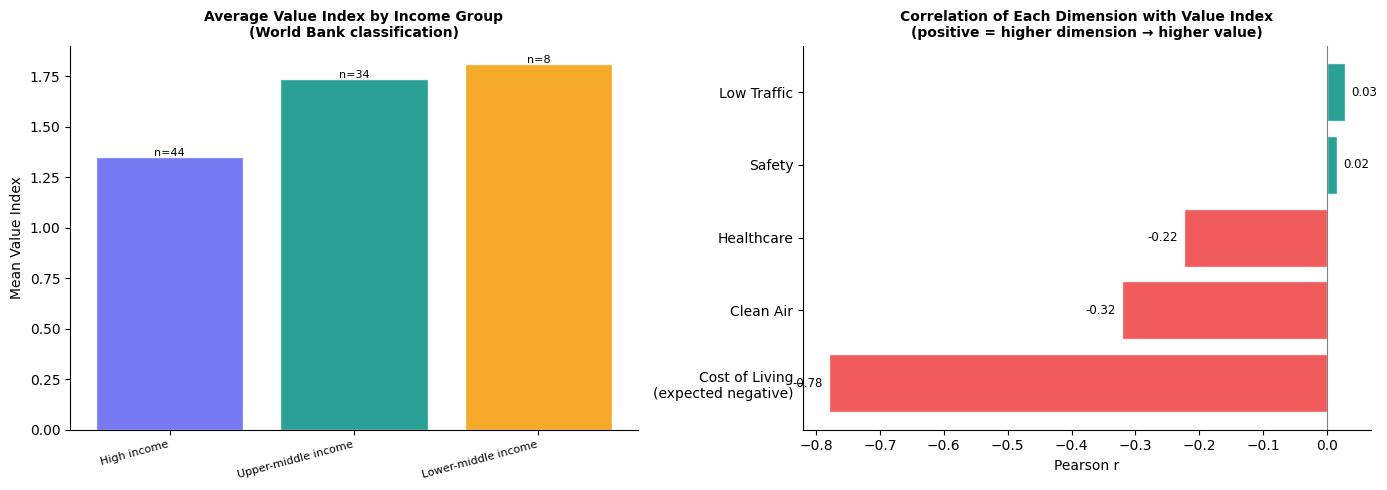

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: income group bar chart
income_order = ['High income', 'Upper-middle income', 'Lower-middle income', 'Low income']
income_colors = ['#6366F1', '#0D9488', '#F59E0B', '#EF4444']
income_data = (
    df_wb.groupby('income_group')['value_index']
    .agg(['mean', 'count'])
    .reindex([g for g in income_order if g in df_wb['income_group'].unique()])
    .reset_index()
)
bars = axes[0].bar(income_data['income_group'], income_data['mean'],
                   color=income_colors[:len(income_data)], edgecolor='white', alpha=0.88)
axes[0].set_title('Average Value Index by Income Group\n'
                  '(World Bank classification)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Mean Value Index')
axes[0].set_xticklabels(income_data['income_group'], rotation=15, ha='right', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, (_, row) in zip(bars, income_data.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"n={int(row['count'])}", ha='center', fontsize=8)

# Panel B: correlation of each sub-index with value_index
dim_labels = {
    'Safety Index':     'Safety',
    'Health Care Index':'Healthcare',
    'pollution_inv':    'Clean Air',
    'traffic_score':    'Low Traffic',
    'Cost of Living Index': 'Cost of Living\n(expected negative)',
}
corrs = {lbl: df[col].corr(df['value_index'])
         for col, lbl in dim_labels.items()}
corr_s = pd.Series(corrs).sort_values()
bar_colors = ['#EF4444' if v < 0 else '#0D9488' for v in corr_s.values]
axes[1].barh(corr_s.index, corr_s.values, color=bar_colors, edgecolor='white', alpha=0.88)
axes[1].axvline(0, color='grey', linewidth=0.8)
axes[1].set_title('Correlation of Each Dimension with Value Index\n'
                  '(positive = higher dimension → higher value)',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Pearson r')
axes[1].spines[['top', 'right']].set_visible(False)
for i, (val, lbl) in enumerate(zip(corr_s.values, corr_s.index)):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i, f'{val:.2f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)

plt.tight_layout()
plt.show()

---
## Section 6: Geographic Distribution

The choropleth maps the value index directly onto countries. Because this is country-level data, no aggregation is needed - each country is coloured by its own value index.

In [10]:
# Plotly locationmode='country names' uses its own spelling for some countries.
# Apply a small mapping for names that differ from Numbeo's.
PLOTLY_NAME_MAP = {
    'Hong Kong (China)':      'Hong Kong',          # Plotly accepts 'Hong Kong'
    'Bosnia And Herzegovina': 'Bosnia and Herzegovina',
    'North Macedonia':        'Macedonia',           # Plotly legacy name
    'South Korea':            'South Korea',         # accepted as-is by Plotly
    'Taiwan':                 'Taiwan',              # accepted as-is
}

df['plotly_name'] = df['Country'].replace(PLOTLY_NAME_MAP)

fig = px.choropleth(
    df,
    locations='plotly_name',
    locationmode='country names',
    color='value_index',
    color_continuous_scale='Teal',
    hover_name='Country',
    title=f'Country Value Index - Quality of Life per Unit of Cost ({YEAR})',
    labels={'value_index': 'Value Index'},
    hover_data={'quality_score': ':.1f', 'Cost of Living Index': ':.1f',
                'plotly_name': False},
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

print(f'Countries plotted: {len(df)}')

Countries plotted: 89


---
## Section 7: Challenging Traditional Liveability Rankings

The EIU Global Liveability Index consistently places Switzerland, Denmark, Norway, Australia, and Japan near the top. These countries are undeniably high-quality - but at what cost? This section places the EIU top countries onto our value index and compares them to our own top countries by cost of living.

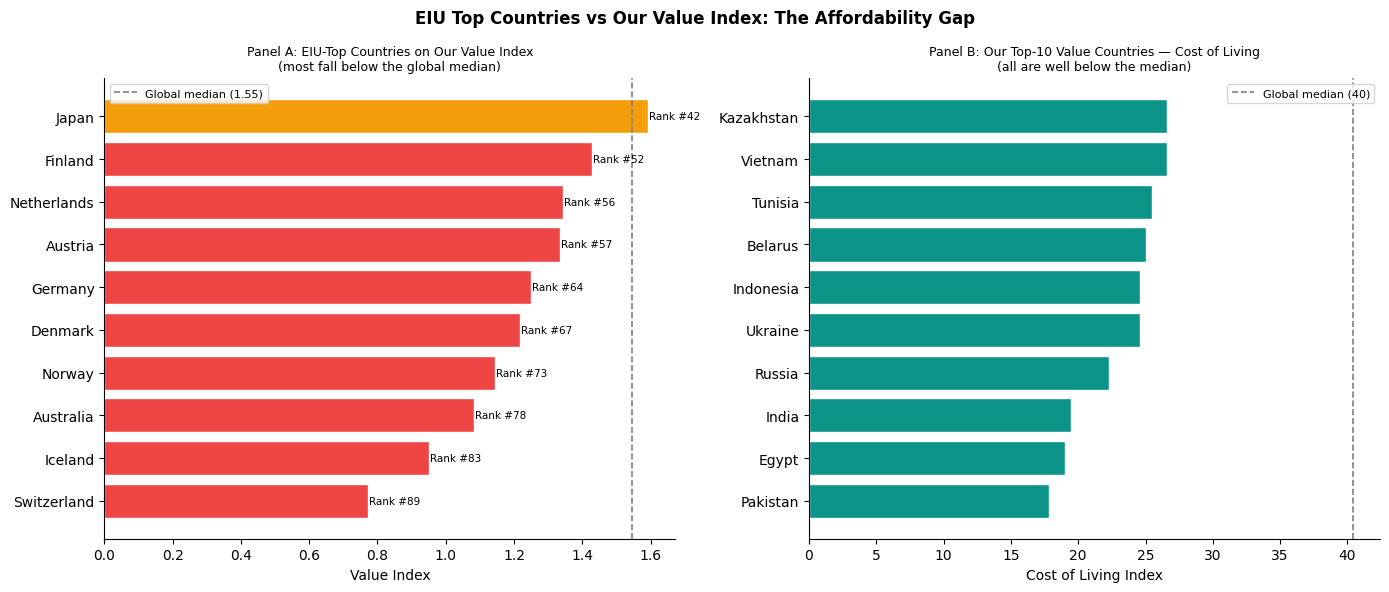


EIU-top countries ranked on our value index:
    Country  value_index  Cost of Living Index  our_rank
      Japan        1.593                  45.6        42
    Finland        1.429                  58.7        52
Netherlands        1.344                  60.5        56
    Austria        1.336                  60.7        57
    Germany        1.251                  58.4        64
    Denmark        1.217                  66.9        67
     Norway        1.143                  69.0        73
  Australia        1.084                  60.9        78
    Iceland        0.950                  83.4        83
Switzerland        0.772                  98.4        89


In [11]:
# EIU-equivalent top countries (using country-level proxies of city top-10)
EIU_TOP = ['Switzerland', 'Denmark', 'Australia', 'Norway', 'Iceland',
           'Japan', 'Austria', 'Germany', 'Netherlands', 'Finland']

df_ranked = df.sort_values('value_index', ascending=False).reset_index(drop=True)
df_ranked['our_rank'] = df_ranked.index + 1

eiu_df   = df_ranked[df_ranked['Country'].isin(EIU_TOP)].copy()
our_top10 = df_ranked.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('EIU Top Countries vs Our Value Index: The Affordability Gap',
             fontsize=12, fontweight='bold')

# Panel A
eiu_sorted = eiu_df.sort_values('value_index')
bar_colors_a = ['#EF4444' if v < df['value_index'].median() else '#F59E0B'
                for v in eiu_sorted['value_index']]
axes[0].barh(eiu_sorted['Country'], eiu_sorted['value_index'],
             color=bar_colors_a, edgecolor='white')
axes[0].axvline(df['value_index'].median(), color='grey', linestyle='--',
                linewidth=1.2, label=f'Global median ({df["value_index"].median():.2f})')
axes[0].set_title('Panel A: EIU-Top Countries on Our Value Index\n'
                  '(most fall below the global median)',
                  fontsize=9)
axes[0].set_xlabel('Value Index')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
for i, (_, row) in enumerate(eiu_sorted.iterrows()):
    axes[0].text(row['value_index'] + 0.003, i,
                 f"Rank #{int(row['our_rank'])}", va='center', fontsize=7.5)

# Panel B
our_sorted = our_top10.sort_values('Cost of Living Index')
axes[1].barh(our_sorted['Country'], our_sorted['Cost of Living Index'],
             color='#0D9488', edgecolor='white')
axes[1].axvline(df['Cost of Living Index'].median(), color='grey', linestyle='--',
                linewidth=1.2, label=f'Global median ({df["Cost of Living Index"].median():.0f})')
axes[1].set_title('Panel B: Our Top-10 Value Countries - Cost of Living\n'
                  '(all are well below the median)',
                  fontsize=9)
axes[1].set_xlabel('Cost of Living Index')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nEIU-top countries ranked on our value index:')
print(eiu_df[['Country', 'value_index', 'Cost of Living Index', 'our_rank']]
      .sort_values('our_rank').to_string(index=False))

---
## Section 8: Consistency Across Years

A country that tops the value ranking in 2025 but was mediocre in prior years is not a reliable recommendation. We check which countries have consistently appeared in the top quartile of value index across the last four years (2022–2025), then plot their full value index trajectory from 2016 to 2025.

Because the country-level index is not NYC-anchored, tracking raw value index values over time is meaningful - a rising line reflects genuine improvement in quality relative to cost, not a measurement artefact.

Countries present in all 10 years: 54

Top 5 most consistently high-value countries (last 4 years):
  Pakistan                        top-quartile in 4/4 yrs  avg vi=2.812
  India                           top-quartile in 4/4 yrs  avg vi=2.239
  Ukraine                         top-quartile in 4/4 yrs  avg vi=2.008
  Colombia                        top-quartile in 4/4 yrs  avg vi=1.854
  Bosnia And Herzegovina          top-quartile in 4/4 yrs  avg vi=1.781


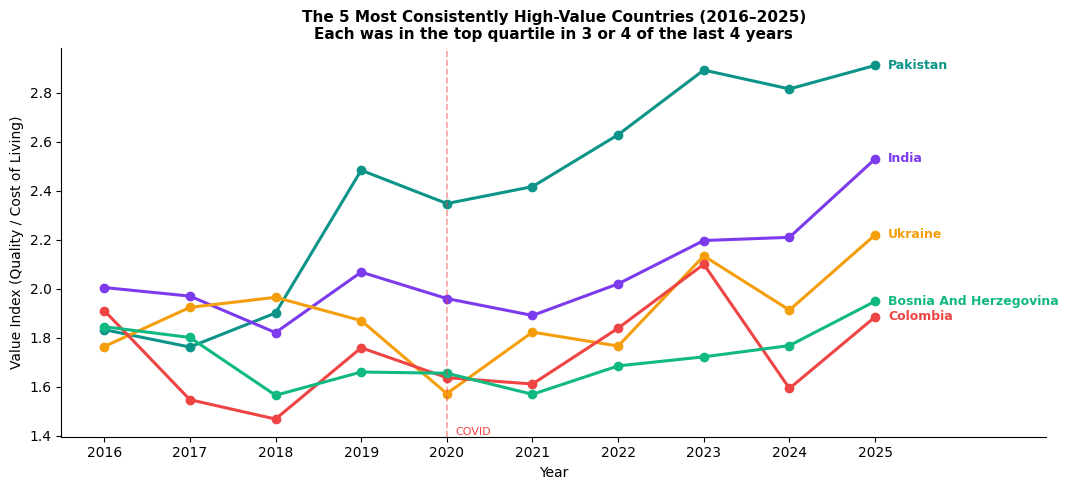

In [12]:
def load_country_file(filepath, years):
    xl = pd.ExcelFile(filepath)
    sheets = [s for s in xl.sheet_names if s.strip().isdigit() and int(s.strip()) in years]
    frames = [pd.read_excel(filepath, sheet_name=s).assign(year=int(s.strip())) for s in sheets]
    return pd.concat(frames, ignore_index=True)

ALL_YEARS = list(range(2016, 2026))

safety_m    = load_country_file('../data/raw/numbeo_crime_country.xlsx',           ALL_YEARS)
health_m    = load_country_file('../data/raw/numbeo_health_care_country.xlsx',     ALL_YEARS)
pollution_m = load_country_file('../data/raw/numbeo_pollution_country.xlsx',       ALL_YEARS)
traffic_m   = load_country_file('../data/raw/number_traffic_country.xlsx',         ALL_YEARS)
cost_m      = load_country_file('../data/raw/numbeo_cost_of_living_country.xlsx',  ALL_YEARS)

panel = (
    cost_m[['Country', 'year', 'Cost of Living Index']]
    .merge(safety_m[['Country', 'year', 'Safety Index']],       on=['Country', 'year'])
    .merge(health_m[['Country', 'year', 'Health Care Index']],  on=['Country', 'year'])
    .merge(pollution_m[['Country', 'year', 'Pollution Index']], on=['Country', 'year'])
    .merge(traffic_m[['Country', 'year', 'Traffic Index']],     on=['Country', 'year'])
)

panel['pollution_inv'] = 100 - panel['Pollution Index']
panel['traffic_score'] = (
    100 * (1 - (panel['Traffic Index'] - TRAFFIC_GLOBAL_MIN)
               / (TRAFFIC_GLOBAL_MAX - TRAFFIC_GLOBAL_MIN))
)
panel['quality_score'] = panel[['Safety Index', 'Health Care Index',
                                 'pollution_inv', 'traffic_score']].mean(axis=1)
panel['value_index']   = (panel['quality_score'] / panel['Cost of Living Index']).round(3)

# Consistent country panel: present in all 10 years across all 5 files
cyc        = panel.groupby('Country')['year'].nunique()
consistent = cyc[cyc == len(ALL_YEARS)].index.tolist()
panel_c    = panel[panel['Country'].isin(consistent)]
print(f'Countries present in all {len(ALL_YEARS)} years: {len(consistent)}')

# Top quartile count 2022-2025
recent_years = [2022, 2023, 2024, 2025]
top_q = {}
for yr in recent_years:
    yr_data = panel_c[panel_c['year'] == yr]
    threshold = yr_data['value_index'].quantile(0.75)
    top_q[yr] = set(yr_data[yr_data['value_index'] >= threshold]['Country'])

top_q_count = {c: sum(c in top_q[yr] for yr in recent_years) for c in consistent}
avg_vi      = panel_c[panel_c['year'].isin(recent_years)].groupby('Country')['value_index'].mean()

top5 = (
    pd.DataFrame({'q_count': pd.Series(top_q_count), 'avg_vi': avg_vi})
    .sort_values(['q_count', 'avg_vi'], ascending=False)
    .head(5).index.tolist()
)

print('\nTop 5 most consistently high-value countries (last 4 years):')
for country in top5:
    print(f'  {country:30s}  top-quartile in {top_q_count[country]}/4 yrs  '
          f'avg vi={avg_vi[country]:.3f}')

# Line chart
trend5     = panel_c[panel_c['Country'].isin(top5)].copy()
colors5    = ['#0D9488', '#7C3AED', '#F59E0B', '#EF4444', '#10B981']
city_order = pd.Series(avg_vi[top5]).sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))
for country, color in zip(city_order, colors5):
    data = trend5[trend5['Country'] == country].sort_values('year')
    ax.plot(data['year'], data['value_index'], marker='o',
            color=color, linewidth=2.2, label='_nolegend_')
    last = data.iloc[-1]
    ax.text(last['year'] + 0.15, last['value_index'],
            country, va='center', fontsize=9, color=color, fontweight='bold')

ax.axvline(2020, color='#EF4444', linestyle='--', alpha=0.5, linewidth=1.2)
ax.text(2020.1, ax.get_ylim()[0], 'COVID', fontsize=8, color='#EF4444', va='bottom')

ax.set_xlim(2015.5, 2027)
ax.set_xticks(ALL_YEARS)
ax.set_xlabel('Year')
ax.set_ylabel('Value Index (Quality / Cost of Living)')
ax.set_title(
    'The 5 Most Consistently High-Value Countries (2016–2025)\n'
    'Each was in the top quartile in 3 or 4 of the last 4 years',
    fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Conclusion: Answers to the Research Question

**Are 'good value' countries clustered in particular world regions?**

Yes, clearly. The top-value countries concentrate in three regions:

1. **Eastern Europe** (Romania, Bulgaria, Serbia, Ukraine, Georgia) - consistently the highest-value region. Strong safety and healthcare scores at costs roughly one-quarter to one-third of Western Europe.

2. **South and Southeast Asia** (India, Vietnam, Indonesia, Bangladesh, Pakistan) - extreme cost advantage. Quality scores are moderate but costs are so low that the value index is high. The limitation is that healthcare and safety scores are more variable within this group.

3. **Latin America** (Ecuador, Colombia, Peru, Brazil) - a mixed picture. Some countries cluster in the sweet-spot quadrant; others are cost traps (high cost relative to their quality, e.g. Venezuela, parts of the Caribbean).

**What are the indicators of high-value countries?**

From the economic indicator analysis:
- **Cost of living is the dominant driver** - the correlation of CoL with value index is strongly negative. Most countries achieve broadly similar quality scores; it is the cost floor that separates sweet spots from expensive countries.
- **GDP per capita is negatively correlated with value index** - higher income countries are systematically more expensive relative to their quality, confirming that existing liveability indices reward wealth as much as quality.
- **Upper-middle income countries** score best on average. Low-income countries have low costs but also low quality scores (especially healthcare). High-income countries have strong quality but prohibitive costs.
- **Clean air and low traffic** scores contribute least to value differences - they are more evenly distributed. **Safety** and **healthcare** are the dimensions that separate high-value countries from low-value countries at the same cost level.

### Limitations
- Country-level aggregation masks intra-country variation: India's national average covers cities from Pune (very high value) to Mumbai (moderate).
- Numbeo data is crowd-sourced; lower-income countries with limited internet penetration have fewer respondents, which may bias quality scores upward (tech-literate users may perceive their city more favourably).
- The analysis captures value for a local resident earning local wages. For international migrants or remote workers, cost-of-living differences matter more and quality perceptions may differ.